<a href="https://colab.research.google.com/github/elvissoares/EQE595-SimMol/blob/main/notebooks/8_Integracao_Termodinamica_Analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carregando as bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Aula Prática 08 - Análise da Integração Termodinâmica de Soluto em Água

Autor: [Prof. Elvis do A. Soares](https://github.com/elvissoares)

Contato: [elvis@peq.coppe.ufrj.br](mailto:elvis@peq.coppe.ufrj.br) - [Programa de Engenharia Química, PEQ/COPPE, UFRJ, Brasil](https://www.peq.coppe.ufrj.br/)

---

Qual molécula?

In [2]:
my_molecule = 'caffeine'  # substitua pelo nome da sua molécula

Carregando o arquivo `.xlsx` produzido por MD

In [4]:
df = pd.read_excel(f'integracao_termodinamica_{my_molecule}.xlsx',sheet_name='nsteps_100_nsamples_2500')

In [5]:
lambda_ele_grid = df['lambda_ele']
U_mean_ele = df['U_ele']
U_std_ele = df['err U_ele']

lambda_steric_grid = df['lambda_steric']
U_mean_steric = df['U_steric']
U_std_steric = df['err U_steric']

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16047/3650105817.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$')


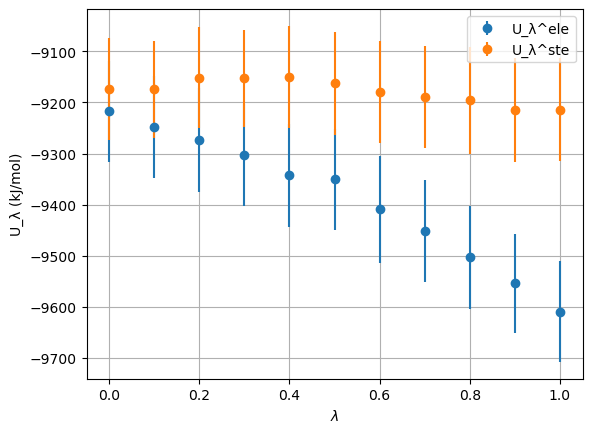

In [18]:
plt.errorbar(lambda_ele_grid, U_mean_ele, yerr=U_std_ele, marker='o',color='C0', label='U_λ^ele',
            linestyle='none')
plt.errorbar(lambda_steric_grid, U_mean_steric, yerr=U_std_steric, marker='o', color='C1', label='U_λ^ste',
            linestyle='none')

plt.xlabel('$\lambda$')
plt.ylabel('U_λ (kJ/mol)')
plt.grid()
plt.legend()

### Definindo um modelo para $U_\lambda$

In [21]:
from scipy.optimize import curve_fit

# função para ajuste de curva
def func(x, a, b, c, d):
    return a  + b * x + c * x**2 + d * x**3

popt_ele, pcov_ele = curve_fit(func, lambda_ele_grid[::-1], U_mean_ele[::-1], sigma=U_std_ele[::-1])
print("Parametros para U_mean_ele:", popt_ele)

popt_steric, pcov_steric = curve_fit(func, lambda_steric_grid[::-1], U_mean_steric[::-1], sigma=U_std_steric[::-1])
print("Parametros para U_mean_steric:", popt_steric)

Parametros para U_mean_ele: [-9219.79251155  -253.44844236   -34.56770017  -104.93415568]
Parametros para U_mean_steric: [-9179.9844013    221.18293672  -504.51292849   246.76297288]


<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16047/1961235116.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$')


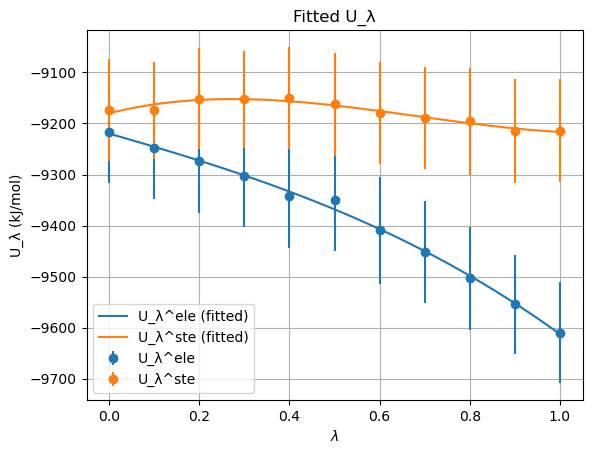

In [22]:
lambda_grid = np.linspace(0.0, 1.0, 100)
U_ele = func(lambda_grid,*popt_ele)
U_steric = func(lambda_grid,*popt_steric)

plt.errorbar(lambda_ele_grid, U_mean_ele, yerr=U_std_ele, marker='o',color='C0', label='U_λ^ele',
            linestyle='none')
plt.errorbar(lambda_steric_grid, U_mean_steric, yerr=U_std_steric, marker='o', color='C1', label='U_λ^ste',
            linestyle='none')

plt.plot(lambda_grid, U_ele, label='U_λ^ele (fitted)', linestyle='-')
plt.plot(lambda_grid, U_steric, label='U_λ^ste (fitted)', linestyle='-')

plt.xlabel('$\lambda$')
plt.ylabel('U_λ (kJ/mol)')
plt.title('Fitted U_λ')
plt.grid()
plt.legend()

### Calculando a derivada $\partial U/\partial \lambda$

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_16047/858026419.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$')


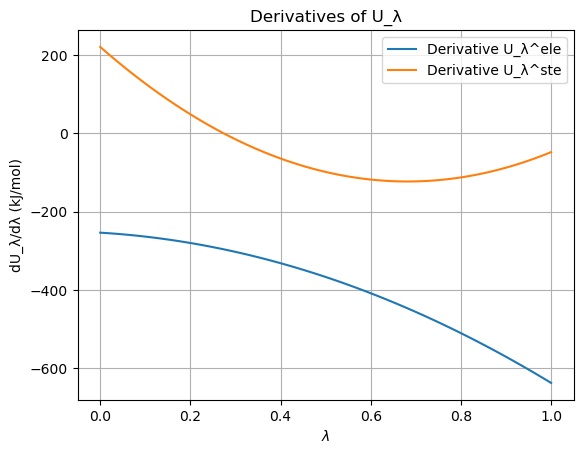

In [23]:
# função para derivada
def deriv(x, a, b, c, d):
    return b  + 2 * c * x + 3 * d * x**2

# Calculate the derivatives of the interpolated functions
dU_ele_dlambda = deriv(lambda_grid,*popt_ele)
dU_steric_dlambda = deriv(lambda_grid,*popt_steric)

# Plot the interpolated U_λ
plt.plot(lambda_grid, dU_ele_dlambda, label='Derivative U_λ^ele', linestyle='-')
plt.plot(lambda_grid, dU_steric_dlambda, label='Derivative U_λ^ste', linestyle='-')

plt.xlabel('$\lambda$')
plt.ylabel('dU_λ/dλ (kJ/mol)')
plt.title('Derivatives of U_λ')
plt.grid()
plt.legend()

### Calculando a diferença de energia livre $\Delta G = \int_0^1 \left\langle \frac{\partial U}{\partial \lambda}\right\rangle \text{d} \lambda$ (Integração Termodinâmica)

In [24]:
deltaG_ele = np.trapezoid(dU_ele_dlambda, lambda_grid)

print(f"ΔG_ele = {deltaG_ele:.3f} kJ/mol")

ΔG_ele = -392.956 kJ/mol


In [25]:
deltaG_steric = np.trapezoid(dU_steric_dlambda, lambda_grid)

print(f"ΔG_steric = {deltaG_steric:.3f} kJ/mol")

ΔG_steric = -36.554 kJ/mol


In [26]:
deltaG = deltaG_ele + deltaG_steric
print(f"ΔG_total = {deltaG:.3f} kJ/mol")

# Convertendo para kcal/mol
deltaG_kcal = deltaG / 4.184 
print(f"ΔG_total = {deltaG_kcal:.3f} kcal/mol")

ΔG_total = -429.510 kJ/mol
ΔG_total = -102.655 kcal/mol


**<span style="color:#A03;font-size:14pt">
&#x270B; HANDS-ON! &#x1F528;
</span>**

> Proponha outro modelo para $U_\lambda$ e efetue o cálculo do $\Delta G$. Seu valor ficou muito diferente do atual?
>